# Tutorial: Parallel Agent Workflows with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0`
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 3_Parallel_Pattern.ipynb`

This walkthrough demonstrates how to build and orchestrate a `Parallel pipeline of agents` using the **AgentGrid SDKs**. We focus on the **RFC (Request for Comments)Compliance Summarizer Agents** 

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama etc) without changing your agent's core logic. The models which are hosted in AIOS as blocks or the 3rd party models like OpenAI/Gemini etc also can be accessed via the `agents_llm` library. As we will use `DSpy Library` for Agentic Programming, we have created a custom class to wrap the `agents_llm` library and provide a more user-friendly interface for model inference `AIOS_DSPy_LMs` custom class

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent.

### Core Data Structures
- **`AgentTask`**: Contains the `job_data` (payload) and metadata.
- **`AgentResult`**: Packages the output or error state.

### The `Context` Object
Every agent is initialized with a `Context`, providing communication handles:
1. **`p2p_manager`**: Synchronous or asynchronous peer-to-peer messaging. The Agent P2P Module enables decentralized, real-time communication between AI agents using WebSocket and HTTP. It supports direct messaging, API calls, file transfer, and remote task execution, making it ideal for distributed multi-agent coordination
2. **`delegator`**: Offloading tasks to specialized workers.
3. **`direct`**: Submitting tasks directly to other without central brokers

### Class Structure

In [ ]:
# sample_agent.py
import logging
import uuid
from typing import List, Optional

from core.agent_executor import AgentTask, AgentResult
from core.main import main
from core.agent_executor import Context

log = logging.getLogger(__name__)


class SampleAgent:

    def __init__(self, subject, context: Context) -> None:
        self.subject = subject
        self.context = context

    def get_muxer(self):
        return None

    def on_preprocess(self, task: AgentTask) -> Optional[List[AgentTask]]:

        text = task.job_data.get("text")
        if not text:
            log.warning(
                "Task %s has no 'text' in job_data, skipping.", task.task_id)
            return None

        return [task]

    def on_data(self, task: AgentTask) -> AgentResult:

        try:
            text = task.job_data["text"]
            out = text.upper()

            if self.context.subject_id == "uppercase-002":

                # agent P2P
                op_x = {}

                op_x = self.context.p2p_manager.send_and_wait_sync(
                    task.task_id, subject_id="uppercase-003",
                    task_data={"text": out + "World!"}
                )

                # using delegate
                op2 = self.context.delegator.submit_and_wait(
                    subject_id="uppercase-003", session_id=str(uuid.uuid4()), task_id=task.task_id, task_data={"text": out}
                )

                # agent direct (doesn't return the result to the caller)
                self.context.direct.submit(to="uppercase-003", session_id=str(uuid.uuid4()), task=task, job_data={
                    "text": "out " + "World!"
                })


                return AgentResult(
                    task_id=task.task_id,
                    job_output=op_x,
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

            else:

                return AgentResult(
                    task_id=task.task_id,
                    job_output={"text": out},
                    job_output_metadata={"length": len(out)},
                    is_error=False,
                )

        except Exception as e:
            log.exception("Error processing task %s: %s", task.task_id, e)
            return AgentResult(
                task_id=task.task_id,
                is_error=True,
                error_data={"stage": "on_data", "message": str(e)},
            )


main(SampleAgent)


### FLOW
1. Use the Base Class Template shared above, and define(specific task) what the agent Class will do with the helps of AI Models and DSPy Library 
2. Use the communication entities to pass on the result of this agent to either next agents ro return the response back to user 
3. Build the docker and push to registry
4. Register the Agent to registry
5. Deploy the Agent Via Deployer
6. Do inference request to the First Agent/Agents

---

## 3. Case Study: RFC Summarizer Task Using Parallel Agentic Flow

The goal is to add a conditional check between specialized agents and move the shared "state" upon condition and aggregate the output to be shared to user.

### Flow Architecture
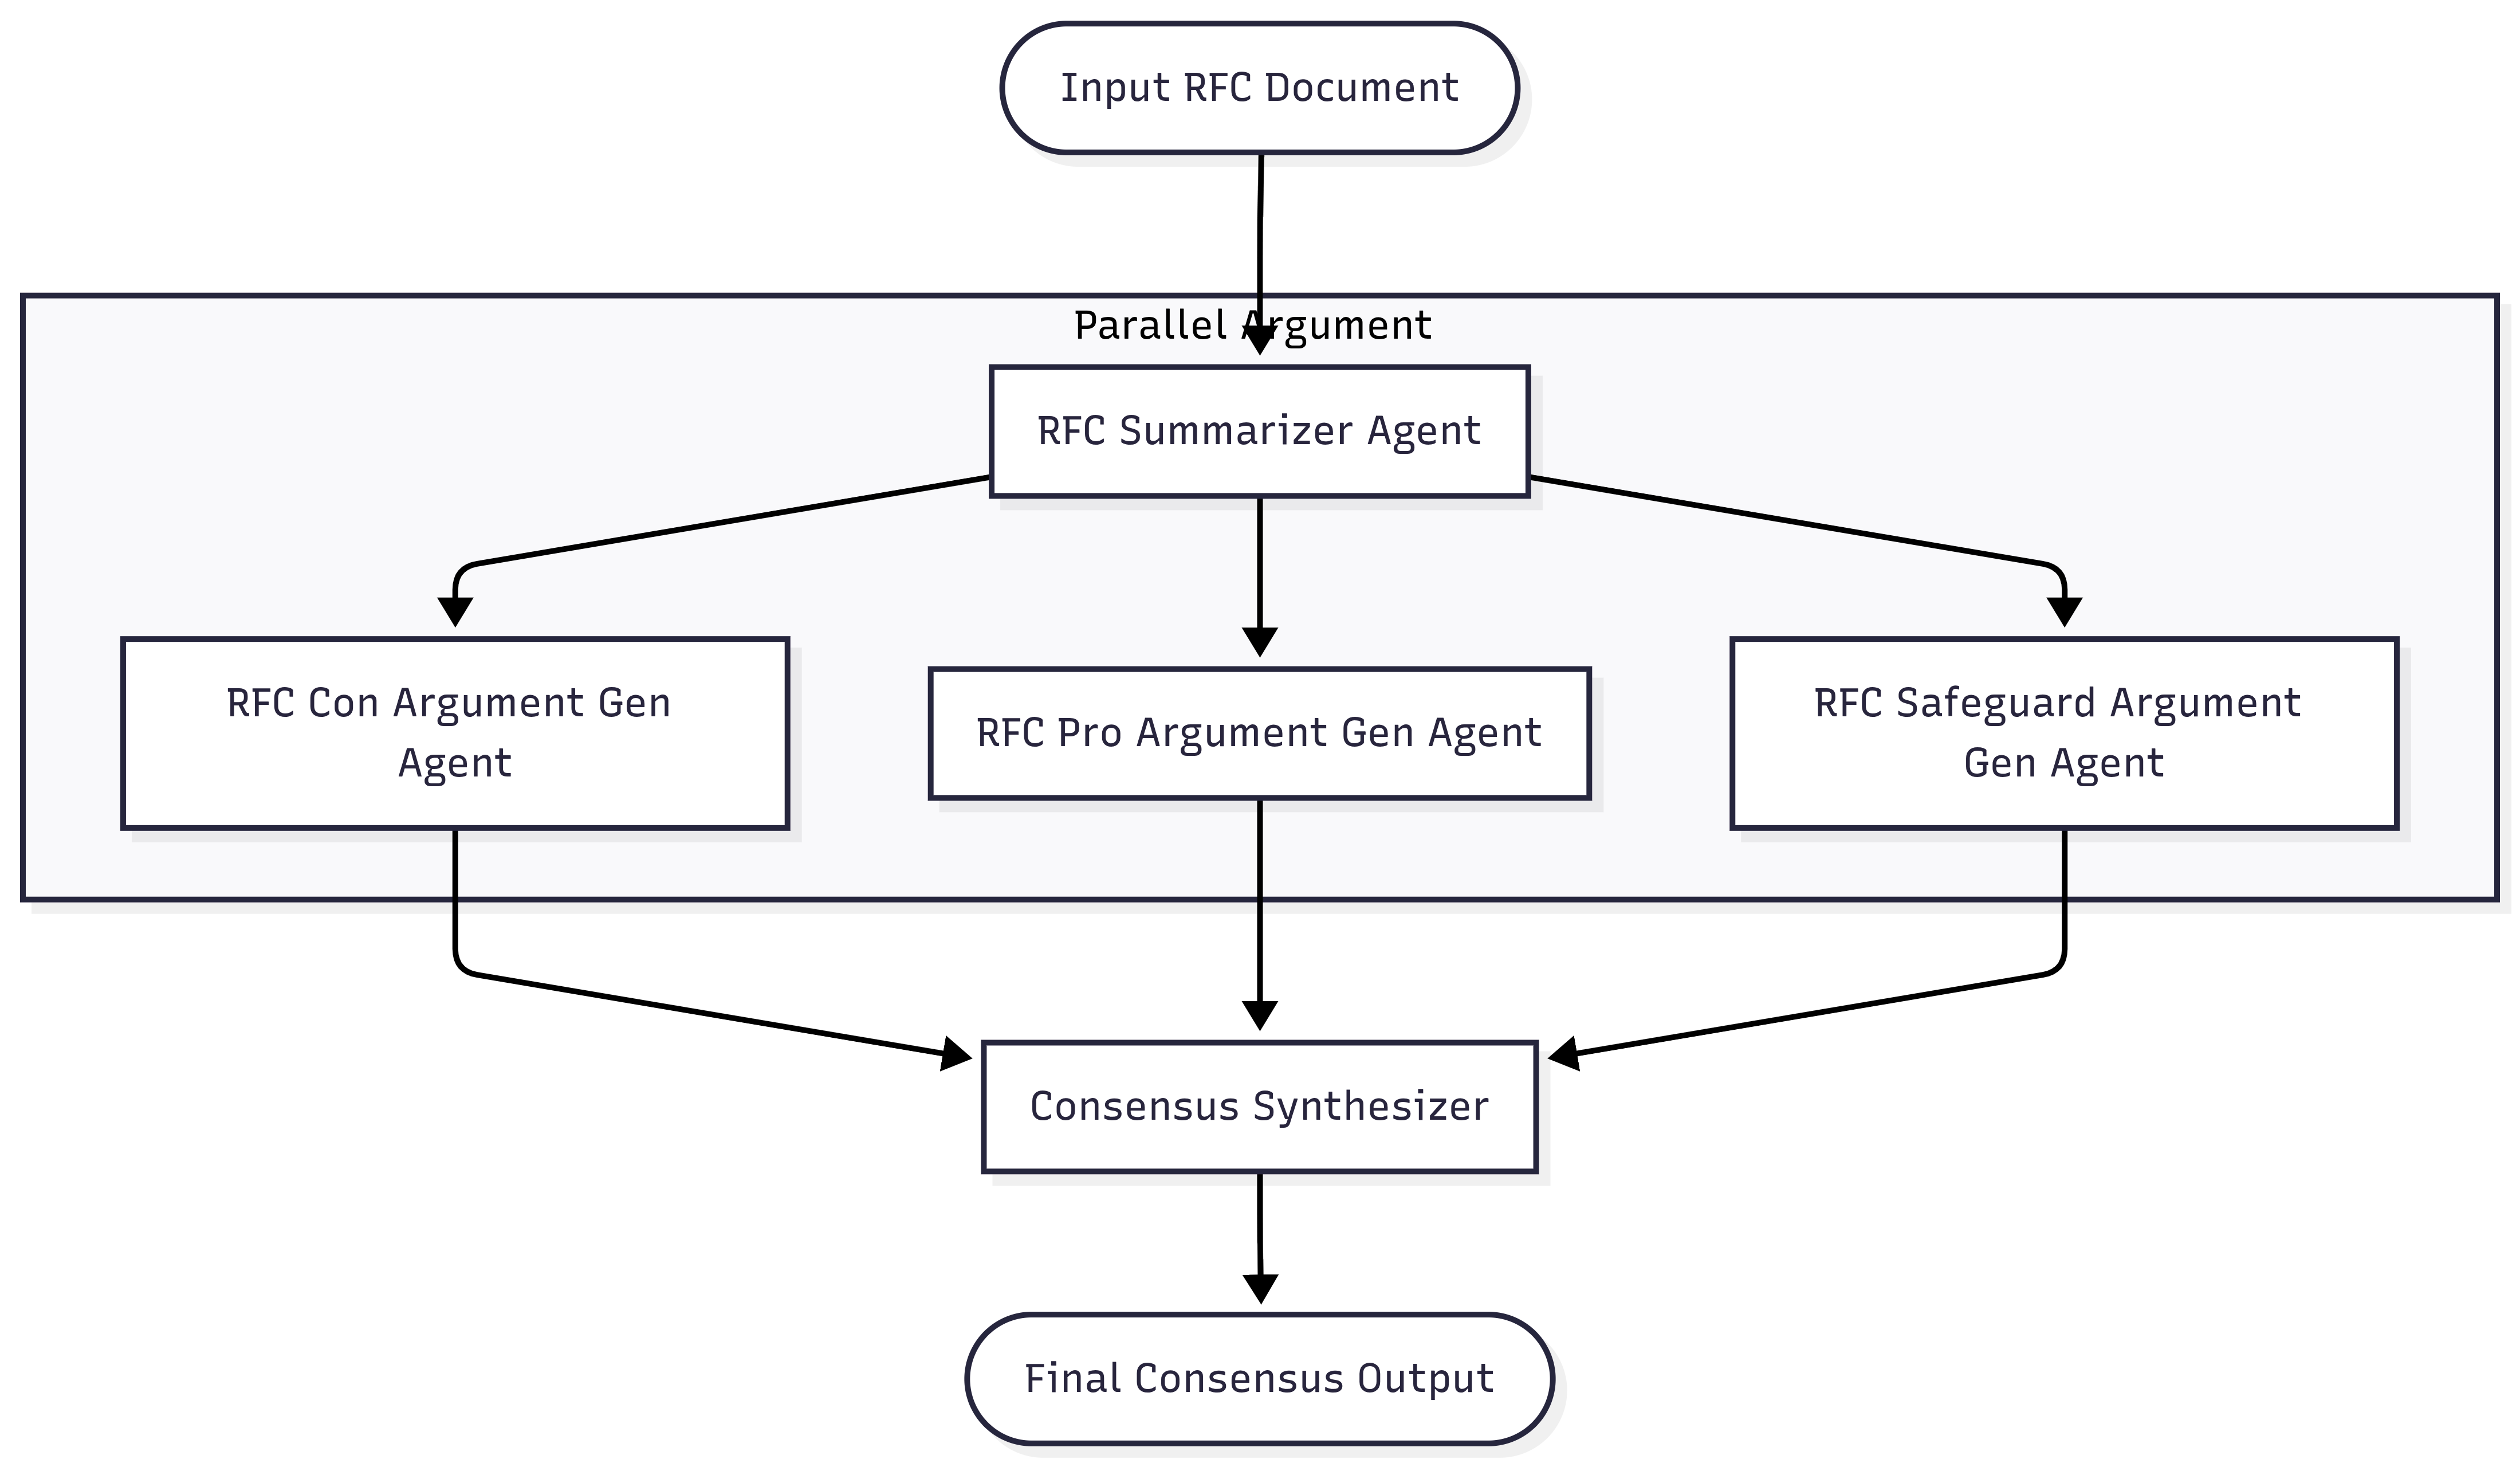

### Agent Roles & Constraints

In this parallel flow, agents perform specialized roles to evaluate an RFC (Request for Comments). The architecture ensures a balanced technical review through concurrent analysis followed by a synthesis step.

#### 1. RFC Summarizer (Splitter/Router)
- **Role**: Neutralizes and structures the incoming RFC text.
- **Workflow**: Acts as the entry point, broadcasting the summary to multiple parallel workers.
- **Output**: Structured RFC Brief.
- **File**: [agent_rfc_rfc_summarizer.py](../../agent_codes/agent_rfc_rfc_summarizer.py)

#### 2. Parallel Evaluation Workers (Fan-Out)
Three agents run concurrently to provide diverse perspectives:
- **Pro Argument Generator**: Creates the "Steel Man" case for the RFC. ([agent_rfc_pro_argument_generator.py](../../agent_codes/agent_rfc_pro_argument_generator.py))
- **Con Argument Generator**: Identifies critical technical risks and downsides. ([agent_rfc_con_argument_generator.py](../../agent_codes/agent_rfc_con_argument_generator.py))
- **Safeguards Proposer**: Suggests concrete constraints and mitigation strategies. ([agent_rfc_safeguards_proposer.py](../../agent_codes/agent_rfc_safeguards_proposer.py))

#### 3. Consensus Synthesizer (Aggregator/Reducer)
- **Role**: Combines outputs from the parallel workers into a final recommendation.
- **Mechanism**: Utilizes a `Muxer` (initialized with `size=3`) to wait for all three perspectives before executing synthesis.
- **File**: [agent_rfc_consensus_synthes1zer.py](../../agent_codes/agent_rfc_consensus_synthesizer.py)

---

### Fan-In Pattern: The Muxer

The parallel pattern relies on a **Fan-In** mechanism to synchronize results. The `Consensus Synthesizer` doesn't start its work until it has received outputs from all three parallel agents. This is handled by a `Muxer` class in the agent's logic.

```python
# Muxer logic in ConsensusSynthesizer
def add(self, key, task: AgentTask):
    if key not in self.packets:
        self.packets[key] = task
        if self.N == 1: return self.packets[key]
    else:
        # Aggregate results into a list for synthesis
        if "text" in self.packets[key].job_data:
            existing_text = self.packets[key].job_data["text"]
            del self.packets[key].job_data["text"]
            self.packets[key].job_data["tasks"] = [existing_text, task.job_data["text"]]
        else:
            self.packets[key].job_data.get("tasks").append(task.job_data.get("text", ""))
        
        if len(self.packets[key].job_data.get("tasks")) == self.N:
            return self.packets[key] # Release task for synthesis
    return None
```

---

## 4. Execution Pipeline

1. **Agent Registration**: Register all RFC agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux/register-agents.sh)
2. **Deployment**: Spin up containers for the RFC evaluation flow.
   - Script: [deploy-agents.sh](../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial RFC text to the **Summarizer**.
   - Script: [inference_request.sh](../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash to setup the RFC Flow

In [ ]:
%%bash
cd ../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux
bash all.bash

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents <PODNAME> -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### Trigger the First agent (Summarizer)

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
cd ../../agents_registration/3_parallel_rfc_pro_con_safegaurds_mux
bash remove-agents.sh